In [ ]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


In [ ]:
# 2. LOAD DATASET
df = pd.read_csv("/content/DSL-StrongPasswordData.csv")   # change path

print("Dataset Shape:", df.shape)

Dataset Shape: (20400, 34)


In [ ]:
# 3. CREATE LABELS
genuine_user = df['subject'].unique()[0]
df['label'] = (df['subject'] != genuine_user).astype(int)
# Drop non-numeric column
df = df.drop(['subject'], axis=1)

In [ ]:
# 4. FEATURES & LABEL
X = df.drop(['label'], axis=1).values
y = df['label'].values

In [ ]:
# 5. NORMALIZATION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 6. TRAIN ONLY ON NORMAL DATA
X_normal = X_scaled[y == 0]
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)


In [ ]:
# 7. AUTOENCODER MODEL
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))
# Encoder
# encoded = Dense(32, activation='relu')(input_layer)
# encoded = Dense(16, activation='relu')(encoded)

# # Decoder
# decoded = Dense(32, activation='relu')(encoded)
# decoded = Dense(input_dim, activation='linear')(decoded)

encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)

decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
# 8. TRAIN MODEL
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=True
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4394 - val_loss: 0.4526
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4032 - val_loss: 0.3989
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3542 - val_loss: 0.3322
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3050 - val_loss: 0.2818
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2657 - val_loss: 0.2429
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2315 - val_loss: 0.2109
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2044 - val_loss: 0.1863
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1835 - val_loss: 0.1701
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1700 - val_loss: 0.1588
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1595 - val_loss: 0.1496
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1502 - val_loss: 0.1417
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1417 - v

In [ ]:
# 9. RECONSTRUCTION ERROR
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

638/638 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
# 10. IMPROVED THRESHOLD (IMPORTANT FIX)
threshold = np.percentile(mse[y == 0], 90)
print("Improved Threshold:", threshold)

Improved Threshold: 0.1086408555460278


In [ ]:
# 11. PREDICTIONS
y_pred = (mse > threshold).astype(int)

In [ ]:
# 12. EVALUATION
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

print("\nClassification Report:")
print(classification_report(y, y_pred))

# Final Accuracy
accuracy = accuracy_score(y, y_pred)
print("\nFinal Accuracy:", accuracy)



Confusion Matrix:
[[  360    40]
 [ 1531 18469]]

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.90      0.31       400
           1       1.00      0.92      0.96     20000

    accuracy                           0.92     20400
   macro avg       0.59      0.91      0.64     20400
weighted avg       0.98      0.92      0.95     20400


Final Accuracy: 0.9229901960784314


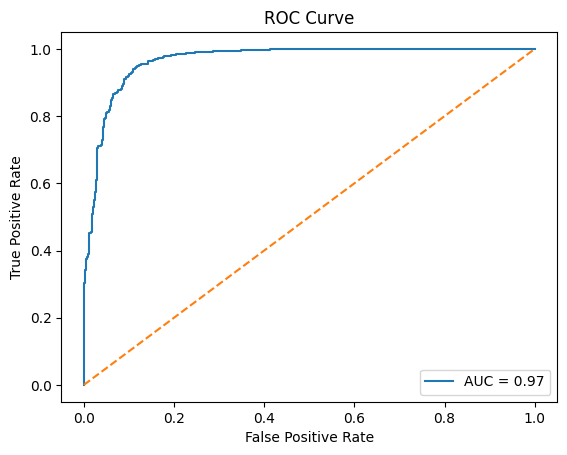

In [ ]:
# 13. ROC CURVE
fpr, tpr, thresholds = roc_curve(y, mse)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
for p in [85, 90, 92, 95]:
    temp_th = np.percentile(mse[y==0], p)
    temp_pred = (mse > temp_th).astype(int)

    print(f"\nThreshold Percentile: {p}")
    print("Accuracy:", accuracy_score(y, temp_pred))
    print("Recall (Intruder):",
          classification_report(y, temp_pred, output_dict=True)['1']['recall'])


Threshold Percentile: 85
Accuracy: 0.9629411764705882
Recall (Intruder): 0.9652

Threshold Percentile: 90
Accuracy: 0.9229901960784314
Recall (Intruder): 0.92345

Threshold Percentile: 92
Accuracy: 0.879656862745098
Recall (Intruder): 0.87885

Threshold Percentile: 95
Accuracy: 0.8118627450980392
Recall (Intruder): 0.8091
